<a href="https://colab.research.google.com/github/Piratesk1/Kubat/blob/main/map_osm_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗺️ OpenStreetMap + Python
Stáhneme část Prahy a prozkoumáme strukturu grafu.

[OpenStreetMap.org](https://www.openstreetmap.org/)

In [15]:
%pip install osmnx

In [17]:
!pip install osmnx

In [18]:
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
#import networkx as nx

## 1) Stažení dat

In [65]:
stred = (50.0755, 14.4378)   # ? náměstí (lat, lon)
polomer =  1000                # metrů

G = ox.graph_from_point(stred, dist=polomer, network_type='drive')

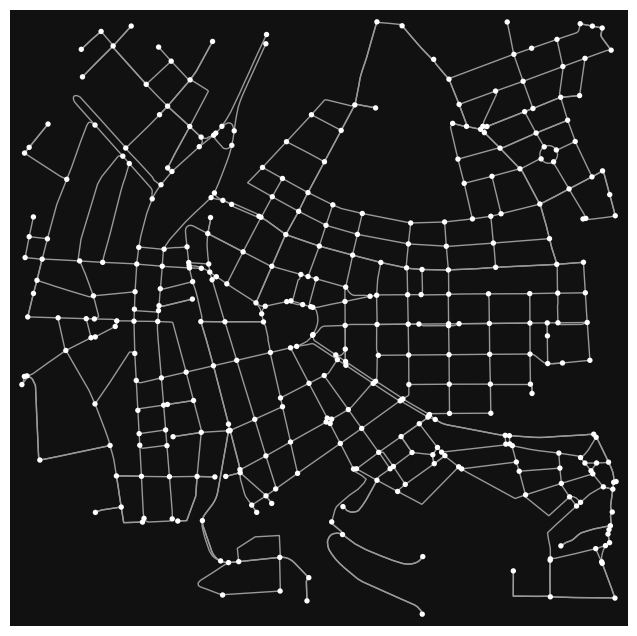

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [66]:
ox.plot_graph(G)

## 2) Základní informace o grafu
Graf.number_of_nodes(),Graf.number_of_edges

In [23]:
# Počet uzlů a hran
print(f"Počet uzlů (křižovatek): {G.number_of_nodes()}")
print(f"Počet hran (úseků cest): {G.number_of_edges()}")

Počet uzlů (křižovatek): 371
Počet hran (úseků cest): 694


In [24]:
pocet_uzlu, pocet_hran = len(G.nodes), len(G.edges)
display([pocet_uzlu, pocet_hran])

[371, 694]

## 3) Struktura uzlu — slovník

In [25]:
type(G.nodes)  # specialni trida NetworkX, má metodu __iter__ (funguje list)

networkx.classes.reportviews.NodeView

In [26]:
list(G.nodes(data=True))[0] # tuple (cislo, slovnik)

(247746, {'y': 50.0773089, 'x': 14.4247582, 'street_count': 4})

In [88]:
# Pro první uzel vypíšeme id_uzlu i slovník data uzlu,
#degree bývá vyšší než street_count, protože jedna obousměrná ulice jsou dvě hrany
id_uzlu, data_uzlu = list(G.nodes(data=True))[0]

print(f"ID uzlu (OSM číslo): {id_uzlu}")
print(f"Typ dat uzlu: {type(data_uzlu)}")
for klic, hodnota in data_uzlu.items():
    print(f"'{klic}': {hodnota}")

ID uzlu (OSM číslo): 2197228
Typ dat uzlu: <class 'dict'>
'y': 50.0740833
'x': 14.4328307
'street_count': 4


### Vypiš informaci o zeměpisné šířce a délce uzlu 20, např. "Uzel číslo 2197228: 50.0755 N, 14.4328 E"

https://www.openstreetmap.org/node/25936035

 100 m odpovídá změně přibližně 0.001° pro zeměpisnou šířku i délku.

In [87]:
node_id = list(G.nodes)[20]
lat = G.nodes[node_id]["y"]
lon = G.nodes[node_id]["x"]
print(f"Uzel číslo {node_id}: {lat:.4f} N, {lon:.4f} E")

Uzel číslo 305807691: 50.0752 N, 14.4302 E


In [86]:

node_id = list(G.nodes)[20]
print(f"Uzel číslo {node_id}: {G.nodes[node_id]['y']:.4f} N, {G.nodes[node_id]['x']:.4f} E")

Uzel číslo 305807691: 50.0752 N, 14.4302 E


In [85]:
# data o uzlu
osmid = 25936035
sirka = 50.0755
delka = 14.4328

# výpis informace
info = f"Uzel číslo {osmid}: {sirka} N, {delka} E"
print(info)

# URL na uzel v OpenStreetMap
url = f"https://www.openstreetmap.org/node/{osmid}"
print(url)

Uzel číslo 25936035: 50.0755 N, 14.4328 E
https://www.openstreetmap.org/node/25936035


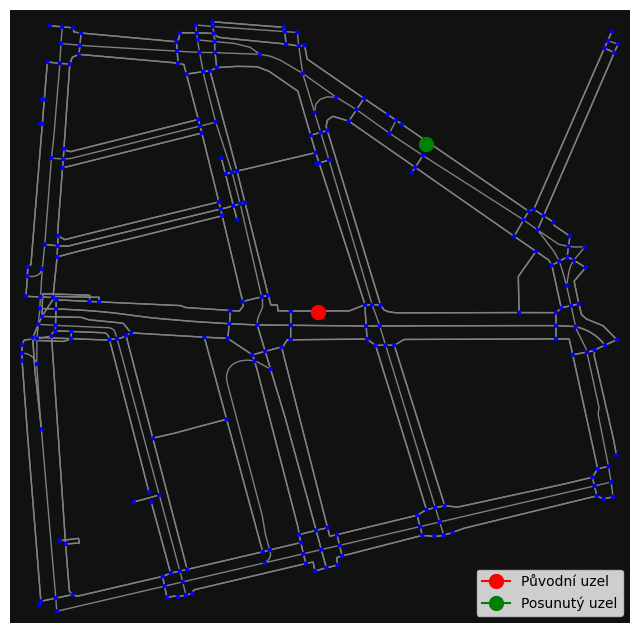

In [84]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# souřadnice uzlu
osmid = 25936035
sirka = 50.0755
delka = 14.4328

# vytvoření grafu oblasti kolem uzlu (buffer 0.002° ~ 200 m)
G = ox.graph_from_point((sirka, delka), dist=200, network_type='all')

# vykreslení grafu
fig, ax = ox.plot_graph(G, node_size=10, node_color='blue', edge_color='gray', show=False, close=False)

# přidání původního uzlu červeně
ax.plot(delka, sirka, marker='o', color='red', markersize=10, label='Původní uzel')

# přidání posunutého uzlu o ~100 m na sever a východ
nova_sirka = sirka + 0.001
nova_delka = delka + 0.001
ax.plot(nova_delka, nova_sirka, marker='o', color='green', markersize=10, label='Posunutý uzel')

ax.legend()
plt.show()

## 4) Struktura hrany — tuple(start, cil,slovník)

defaultně je data = False - vypíše NODE ID pro start, cíl a nakonec nezajímavý identifikátor hrany pro multigraf.

In [32]:
list(G.edges)[0]  # specialni trida NetworkX, má metodu __iter__ (funguje list)

(2197228, 1434214288, 0)

In [83]:
list(G.edges(data=True))[10]

(8809993,
 12878702472,
 {'osmid': [325508897, 68172942],
  'highway': 'primary',
  'lanes': '3',
  'maxspeed': '50',
  'name': 'Legerova',
  'oneway': True,
  'ref': '8',
  'reversed': False,
  'length': np.float64(142.33904821799374),
  'geometry': <LINESTRING (14.431 50.069, 14.431 50.069, 14.431 50.07, 14.431 50.07, 14.43...>})

Užitím osmid můžeme hranu zobrazit v OSM: https://www.openstreetmap.org/way/217476454

In [82]:
# Výpis pro první hranu
u, v, data_hrany = list(G.edges(data=True))[0]

print(f"Hrana: uzel {u}  →  uzel {v}")
print(f"Typ dat hrany: {type(data_hrany)}")
print()
for klic, hodnota in data_hrany.items():
    if klic == 'geometry':
        print(f"  '{klic}': <geometrie>")
    else:
        print(f"  '{klic}': {hodnota}")

Hrana: uzel 247746  →  uzel 25935957
Typ dat hrany: <class 'dict'>

  'osmid': 128494848
  'highway': residential
  'lanes': 1
  'name': Štěpánská
  'oneway': True
  'reversed': False
  'length': 70.50731856403189
  'geometry': <geometrie>


### Vypiš informaci o 10. hraně, např. "osmid 217476454: Rumunská",

Vytvoř string pro URL na hranu

https://www.openstreetmap.org/way/217476454


In [81]:
edge = list(G.edges(data=True))[10]
osmid = edge[2]["osmid"]
name = edge[2].get("name", "bez názvu")

print(f"osmid {osmid}: {name}")

url = f"https://www.openstreetmap.org/way/{osmid}"
print(url)

osmid [325508897, 68172942]: Legerova
https://www.openstreetmap.org/way/[325508897, 68172942]


## 5) Zajímavé statistiky

Užijeme hodnoty klíče `length` ve slovníku `data_hrany`

* Nejkratší úsek:  2.8 m
* Nejdelší úsek:   207.6 m
* Průměrná délka:  76.9 m
* Celková délka:   18.16 km

In [80]:
# Délky hran
delky = [data_hrany['length'] for u, v, data_hrany in G.edges(data=True) if 'length' in data_hrany]

print(f"Nejkratší úsek:  {min(delky):.1f} m")
print(f"Nejdelší úsek:   {max(delky):.1f} m")
print(f"Průměrná délka:  {sum(delky) / len(delky):.1f} m")
print(f"Celková délka:   {sum(delky) / 1000:.2f} km")

Nejkratší úsek:  2.8 m
Nejdelší úsek:   485.1 m
Průměrná délka:  93.8 m
Celková délka:   65.09 km


Užijeme hodnoty klíče `highway` ve slovníku `data_hrany`
* residential               139 úseků
* tertiary                  68 úseků
*  secondary                 21 úseků
* living_street             5 úseků

In [79]:
# Typy ulic
typy = {}
for u, v, d in G.edges(data=True):
    typ = d.get('highway', 'neznámý')
    if isinstance(typ, list):
        typ = typ[0]
    typy[typ] = typy.get(typ, 0) + 1

print("Typy ulic:")
for typ, pocet in sorted(typy.items(), key=lambda x: -x[1]):
    print(f"  {typ:<25} {pocet} úseků")

Typy ulic:
  residential               435 úseků
  tertiary                  169 úseků
  primary                   46 úseků
  secondary                 27 úseků
  living_street             13 úseků
  tertiary_link             2 úseků
  secondary_link            1 úseků
  primary_link              1 úseků


In [55]:
# Křižovatka s nejvíce cestami
stupne = dict(G.degree())
id_max = max(stupne, key=stupne.get)

print(f"Nejsložitější křižovatka:")
print(f"  ID uzlu:      {id_max}")
print(f"  Počet cest:   {stupne[id_max]}")

Nejsložitější křižovatka:
  ID uzlu:      317008019
  Počet cest:   8


In [56]:
# Křižovatka s nejvíce cestami
stupne = dict(G.degree())
id_max = max(stupne, key=stupne.get)

print(f"Nejsložitější křižovatka:")
print(f"  ID uzlu:      {id_max}")
print(f"  Počet cest:   {stupne[id_max]}")

Nejsložitější křižovatka:
  ID uzlu:      317008019
  Počet cest:   8


## 6) Nejbližší uzel k zadaným souřadnicím

In [ ]:
#import numpy as np, zanedbám np.sqrt

def nejblizsi_uzel(G, lon, lat):
    # Projde všechny uzly a najde nejbližší k zadanému bodu
    # n - NODE ID, d['x'] - délka, d['y'] - šířka
    uzly = [(n, d['x'], d['y']) for n, d in G.nodes(data=True)]
    vzdalenosti = [(n, ((x - lon)**2 + (y - lat)**2)) for n, x, y in uzly]
    return min(vzdalenosti, key=lambda x: x[1])[0]

# Zadej libovolné souřadnice (lon, lat)
lon = 14.4350
lat = 50.0760

uzel = nejblizsi_uzel(G, lon, lat)
data = G.nodes[uzel]

print(f"Hledám uzel nejblíže: lon={lon}, lat={lat}")
print(f"  ID uzlu: {uzel}")
print(f"  Souřadnice uzlu: lon={data['x']:.5f}, lat={data['y']:.5f}")

Hledám uzel nejblíže: lon=14.435, lat=50.076
  ID uzlu: 25936036
  Souřadnice uzlu: lon=14.43380, lat=50.07650


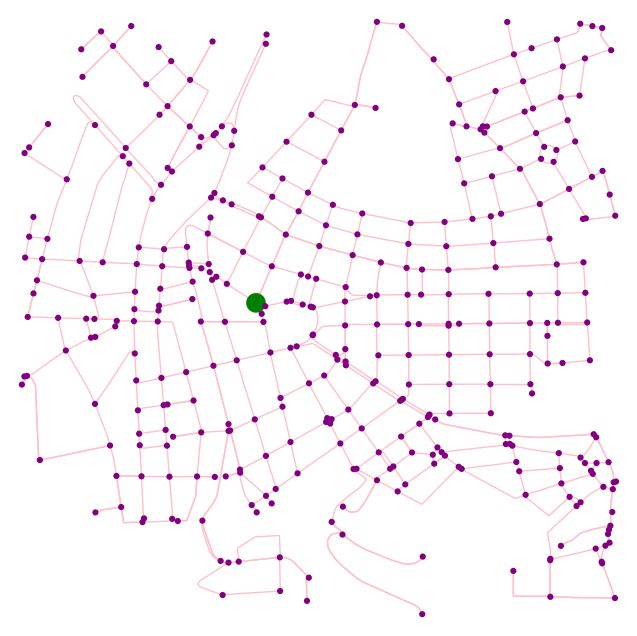

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [78]:
node = 25936052

node_sizes  = [200 if n == node else 20 for n in G.nodes]
node_colors = ["green" if n == node else "purple" for n in G.nodes]

ox.plot_graph(G, node_size=node_sizes, node_color=node_colors,
              edge_color="pink", bgcolor="white")

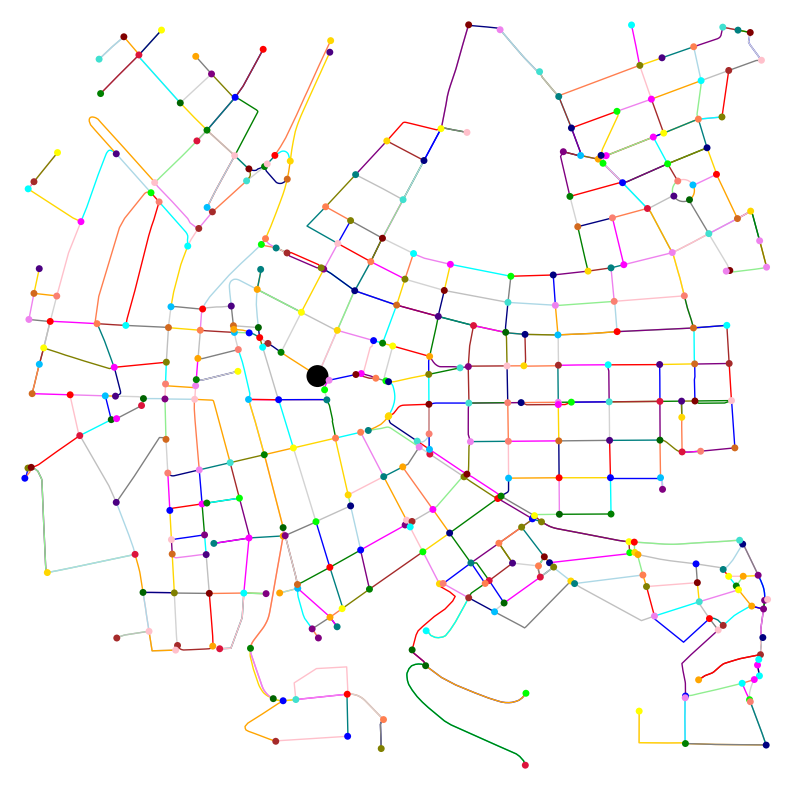

In [77]:
import osmnx as ox
import matplotlib.pyplot as plt

node = 25936052

color_palette = [
"red","blue","green","yellow","orange","purple","pink","brown","cyan","magenta",
"lime","navy","gold","teal","coral","olive","maroon","turquoise","violet","salmon",
"chocolate","indigo","crimson","darkgreen","deepskyblue"
]

node_sizes = []
node_colors = []

nodes_list = list(G.nodes)

for i, n in enumerate(nodes_list):
    if n == node:
        node_sizes.append(250)
        node_colors.append("black")
    else:
        node_sizes.append(25)
        node_colors.append(color_palette[i % len(color_palette)])

edge_palette = [
"lightgray","gray","silver","lightblue","lightgreen",
"orange","pink","violet","gold","cyan",
"red","blue","green","purple","brown",
"olive","teal","coral","magenta","navy"
]

edge_colors = []

edges_list = list(G.edges)

for i, e in enumerate(edges_list):
    edge_colors.append(edge_palette[i % len(edge_palette)])

fig, ax = ox.plot_graph(
    G,
    node_size=node_sizes,
    node_color=node_colors,
    edge_color=edge_colors,
    bgcolor="white",
    figsize=(10,10)
)

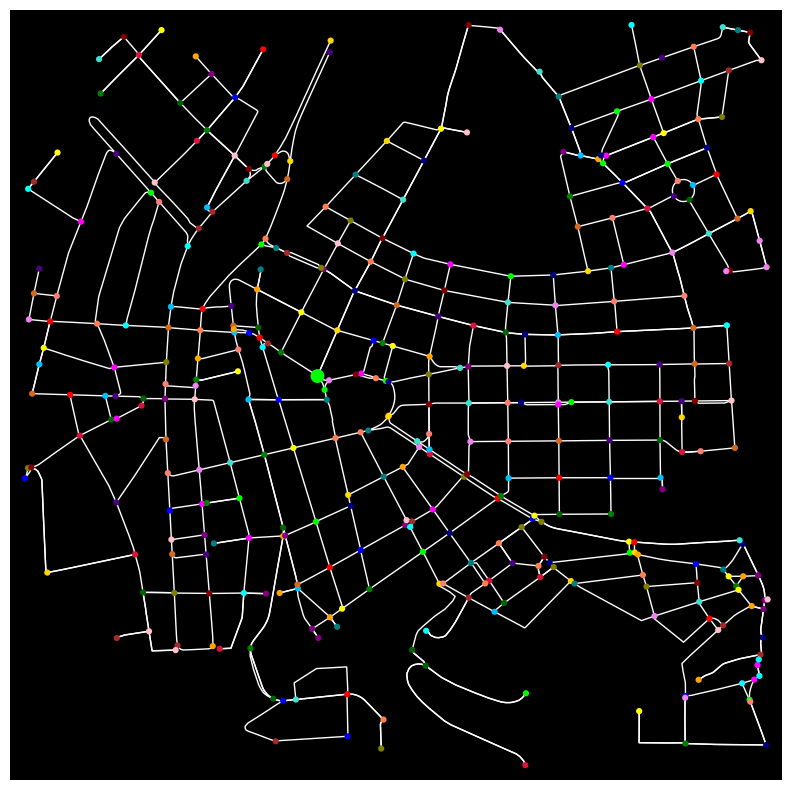

In [69]:
import osmnx as ox
import matplotlib.pyplot as plt

node = 25936052

color_palette = [
"red","blue","green","yellow","orange","purple","pink","brown","cyan","magenta",
"lime","navy","gold","teal","coral","olive","maroon","turquoise","violet","salmon",
"chocolate","indigo","crimson","darkgreen","deepskyblue"
]

node_sizes = []
node_colors = []

nodes_list = list(G.nodes)
for i, n in enumerate(nodes_list):
    if n == node:
        node_sizes.append(100)
        node_colors.append("lime")
    else:
        node_sizes.append(20)
        node_colors.append(color_palette[i % len(color_palette)])

edge_colors = ["white" for e in G.edges]

fig, ax = ox.plot_graph(
    G,
    node_size=node_sizes,
    node_color=node_colors,
    edge_color=edge_colors,
    bgcolor="black",
    figsize=(10,10)
)